In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import os

dataset_path = r"dataset\Garbage classification\Garbage classification"

print("Classes:")
print(os.listdir(dataset_path))

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
import os

dataset_path = r"dataset\Garbage classification\Garbage classification"

image_extensions = ('.jpg', '.jpeg', '.png')

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        count = sum(
            1 for f in os.listdir(category_path)
            if f.lower().endswith(image_extensions)
        )

        print(f"{category}: {count}")

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


In [4]:
import tensorflow as tf

dataset_path = r"dataset\Garbage classification\Garbage classification"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),   # same size as CIFAR-10
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [5]:
classes = train_ds.class_names

print(classes)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Dropout
)

model = Sequential()

model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))   # 6 classes

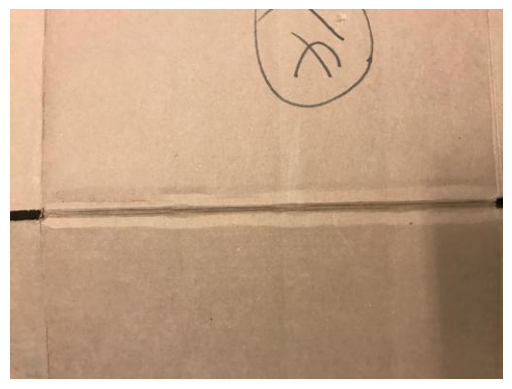

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

dataset_path = r"dataset\Garbage classification\Garbage classification"

category = "cardboard"

image_file = os.listdir(
    os.path.join(dataset_path, category)
)[0]

image_path = os.path.join(
    dataset_path,
    category,
    image_file
)

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.2097 - loss: 40.3151 - val_accuracy: 0.2911 - val_loss: 1.7366
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.2488 - loss: 1.7155 - val_accuracy: 0.3386 - val_loss: 1.6519
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.2913 - loss: 1.7049 - val_accuracy: 0.3327 - val_loss: 2.4832
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.3027 - loss: 1.6698 - val_accuracy: 0.3168 - val_loss: 1.6375
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.3086 - loss: 1.6417 - val_accuracy: 0.3030 - val_loss: 1.6069
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.3284 - loss: 1.5948 - val_accuracy: 0.3327 - val_loss: 1.6245
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.3566 - loss: 1.5824 - val_accuracy: 0.3584 - val_loss: 1.6016
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.3501 - loss: 1.5559 - val_acc

In [10]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3782 - loss: 1.5324
Test Accuracy: 0.37821781635284424
